In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))



import pandas as pd
import matplotlib.pyplot as plt
from src.db import get_connection

conn = get_connection()
df = pd.read_sql_query("SELECT * FROM ticket_scores", conn)
conn.close()

df.head()

Matplotlib is building the font cache; this may take a moment.


,id,ticket_key,summary,priority,elapsed_hrs,sla_hrs,pct_of_sla_used,status,run_timestamp
0,1,KAN-6,Login page throwing 500 error,Highest,479.4,4.0,11985.9,BREACHED,2026-09-02 11:24:13
1,2,KAN-7,Payment gateway timeout on checkout,Highest,479.3,4.0,11983.7,BREACHED,2026-09-02 11:24:13
2,3,KAN-9,Customer data not syncing after account merge,Highest,479.3,4.0,11983.4,BREACHED,2026-09-02 11:24:13
3,4,KAN-8,Production database connection pool exhausted,Highest,479.3,4.0,11983.4,BREACHED,2026-09-02 11:24:13
4,5,KAN-12,Email notifications delayed by 2+ hours,High,479.2,8.0,5989.7,BREACHED,2026-09-02 11:24:13


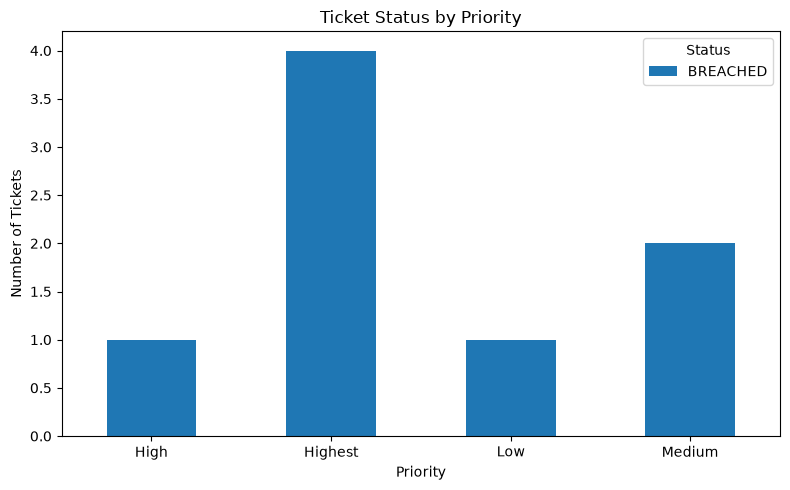

In [2]:
# Breach distribution by priority
priority_counts = df.groupby('priority')['status'].value_counts().unstack(fill_value=0)
priority_counts.plot(kind='bar', stacked=True, figsize=(8, 5))
plt.title('Ticket Status by Priority')
plt.xlabel('Priority')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=0)
plt.legend(title='Status')
plt.tight_layout()
plt.show()

# SLA Sentinel — Exploratory Analysis (Phase 0)

Analysis of ticket data collected from the Jira sandbox, showing breach distribution
by priority and overall SLA usage patterns. This will be re-run against real historical
data once production Jira access is available.